# Lab 1 DS & AI - DQ
# Influence of Data Quality on Machine Learning performance

**Authors**: <br> Luís Forti - 3981932 <br>
Marcell Slyuch - 3992616 <br>
Ntando Thato Mazinyane - 3987639 <br>

In this lab we will explore different data quality problems and their possible effect on classification or regression tasks. To help you to start quickly with this lab, the notebook below already implements a basic Regression and Classification task. You can do the exercises by taking this code and modify/extend it. 

## Import Relevant Libraries

In [1]:
# Uncomment if needed and restart the Kernel after installation
# %pip install seaborn
# %pip install scipy
# %pip install scikit-learn

In [2]:
# If you get an error on the import of the seaborn package below, then you need to install
# it first with 'pip' in the above box. Uncomment the '%pip' line, execute the cell, comment it again,
# and do a restart of the kernel (top Menu bar, menu 'Kernel', menu-item 'Restart Kernel'

import matplotlib.pyplot as plt
from scipy.io import arff
import seaborn as sns
import pandas as pd
import warnings
import os
import random

warnings.filterwarnings("ignore", module=r"matplotlib\..*")

## Load Data
Some files are stored as an arff file, for which you can use the function below to load it into a pandas dataframe. An ARFF file can be viewed with a text editor; please do because it often contains documentation among other things about the meaning of the various attributes.

In [3]:
def load_arff(file_path):
    '''Return a pandas dataframe and meta data from an arff file.'''
    ar, meta = arff.loadarff(file_path)
    return pd.DataFrame(ar), meta

# Classification
---
We will work with a credit approval dataset, where the goal is to classify whether a credit will be approved or not based on several input variables.

### Load the Data
Let's load in some data with which we will try to perform a classification on and print its meta data information to get a first overview.

In [4]:
# The dataset may be located in different places depending on your setup.
# We try a few common locations and use the first one that exists.
candidate_locations = [
    "credit-a.arff",                                                    # same folder as the notebook
    os.path.join("Datasets", "Datasets", "uci-large", "credit-a.arff"), # original lab layout
    os.path.join("Datasets", "uci-large", "credit-a.arff"),
    os.path.join("uci-large", "credit-a.arff"),
]

path = next((p for p in candidate_locations if os.path.exists(p)), None)
if path is None:
    raise FileNotFoundError("credit-a.arff not found - adjust 'candidate_locations' to point to the file.")

# Load the arff file and print the meta information
data, meta = load_arff(path)
print(meta)

Dataset: credit-rating
	A1's type is nominal, range is ('b', 'a')
	A2's type is numeric
	A3's type is numeric
	A4's type is nominal, range is ('u', 'y', 'l', 't')
	A5's type is nominal, range is ('g', 'p', 'gg')
	A6's type is nominal, range is ('c', 'd', 'cc', 'i', 'j', 'k', 'm', 'r', 'q', 'w', 'x', 'e', 'aa', 'ff')
	A7's type is nominal, range is ('v', 'h', 'bb', 'j', 'n', 'z', 'dd', 'ff', 'o')
	A8's type is numeric
	A9's type is nominal, range is ('t', 'f')
	A10's type is nominal, range is ('t', 'f')
	A11's type is numeric
	A12's type is nominal, range is ('t', 'f')
	A13's type is nominal, range is ('g', 'p', 's')
	A14's type is numeric
	A15's type is numeric
	class's type is nominal, range is ('+', '-')



## Data Preparation
Lets take a deeper look at the data and see if we can make some interesting observations.

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A1      690 non-null    object 
 1   A2      678 non-null    float64
 2   A3      690 non-null    float64
 3   A4      690 non-null    object 
 4   A5      690 non-null    object 
 5   A6      690 non-null    object 
 6   A7      690 non-null    object 
 7   A8      690 non-null    float64
 8   A9      690 non-null    object 
 9   A10     690 non-null    object 
 10  A11     690 non-null    float64
 11  A12     690 non-null    object 
 12  A13     690 non-null    object 
 13  A14     677 non-null    float64
 14  A15     690 non-null    float64
 15  class   690 non-null    object 
dtypes: float64(6), object(10)
memory usage: 86.4+ KB


Here we can already observe that there exist some Null values in the table. Column `A2` and `A14` apparently have some null values (less non null values than the other columns). 
In this case we will deal with the null values by dropping them from the dataset.

In [6]:
# remove all Nan values
data.dropna(inplace=True)

We will now take a look inside the data with the first 5 rows.

In [7]:
data.head()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,class
0,b'b',30.83,0.000,b'u',b'g',b'w',b'v',1.25,b't',b't',1.0,b'f',b'g',202.0,0.0,b'+'
1,b'a',58.67,4.460,b'u',b'g',b'q',b'h',3.04,b't',b't',6.0,b'f',b'g',43.0,560.0,b'+'
2,b'a',24.50,0.500,b'u',b'g',b'q',b'h',1.50,b't',b'f',0.0,b'f',b'g',280.0,824.0,b'+'
3,b'b',27.83,1.540,b'u',b'g',b'w',b'v',3.75,b't',b't',5.0,b't',b'g',100.0,3.0,b'+'
4,b'b',20.17,5.625,b'u',b'g',b'w',b'v',1.71,b't',b'f',0.0,b'f',b's',120.0,0.0,b'+'


We can observe that the nominal features are stored as an byte object (prefixed with a b like `b'a'`) . It is possible to convert the byte data type with the `decode()` function to strings.

In [8]:
# save which columns are nominal
nominal = []

for col, typ in zip(data.columns, data.dtypes):
    if(typ == 'object'):
        # Decode the byte object for the whole column
        data[col] = data[col].map(lambda x: x.decode())
        # remember the nominal column for later
        nominal.append(col)
        
data.head()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,class
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1.0,f,g,202.0,0.0,+
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6.0,f,g,43.0,560.0,+
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0.0,f,g,280.0,824.0,+
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5.0,t,g,100.0,3.0,+
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0.0,f,s,120.0,0.0,+


We will be working with a Naive Bayes classifier, but this ML method can only receive numerical data as its input. Therefore, we need to translate our nominal data to numeric. Because we have nominal data that does not have any ordering, we can apply **one hot encoding** to the nominal data. The pandas library contains the `get_dummies()` function that helps us to create these one hot encodings for nominal variables.

In [9]:
# Exclude the class label variable
nominal = nominal[0:-1]
# Show how the one hot encoding looks
pd.get_dummies(data[nominal[0]])

,?,a,b
0,False,False,True
1,False,True,False
2,False,True,False
3,False,False,True
4,False,False,True
...,...,...,...
685,False,False,True
686,False,True,False
687,False,True,False
688,False,False,True


In [10]:
# create one hot encoding for all variables
dummies = pd.get_dummies(data[nominal])
# Concatenate with df and drop nominal columns
data = pd.concat([data, dummies], axis=1).drop(nominal, axis=1)

# remove the the encodings that end with ? since they contain only 0
data.drop([col for col in data.columns if col.endswith('_?')], axis=1, inplace=True)
data.head()

,A2,A3,A8,A11,A14,A15,class,A1_a,A1_b,A4_l,...,A7_z,A9_f,A9_t,A10_f,A10_t,A12_f,A12_t,A13_g,A13_p,A13_s
0,30.83,0.000,1.25,1.0,202.0,0.0,+,False,True,False,...,False,False,True,False,True,True,False,True,False,False
1,58.67,4.460,3.04,6.0,43.0,560.0,+,True,False,False,...,False,False,True,False,True,True,False,True,False,False
2,24.50,0.500,1.50,0.0,280.0,824.0,+,True,False,False,...,False,False,True,True,False,True,False,True,False,False
3,27.83,1.540,3.75,5.0,100.0,3.0,+,False,True,False,...,False,False,True,False,True,False,True,True,False,False
4,20.17,5.625,1.71,0.0,120.0,0.0,+,False,True,False,...,False,False,True,True,False,True,False,False,False,True


After the one hot encoding, our dataframe contains 47 columns.

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 666 entries, 0 to 689
Data columns (total 47 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A2      666 non-null    float64
 1   A3      666 non-null    float64
 2   A8      666 non-null    float64
 3   A11     666 non-null    float64
 4   A14     666 non-null    float64
 5   A15     666 non-null    float64
 6   class   666 non-null    object 
 7   A1_a    666 non-null    bool   
 8   A1_b    666 non-null    bool   
 9   A4_l    666 non-null    bool   
 10  A4_u    666 non-null    bool   
 11  A4_y    666 non-null    bool   
 12  A5_g    666 non-null    bool   
 13  A5_gg   666 non-null    bool   
 14  A5_p    666 non-null    bool   
 15  A6_aa   666 non-null    bool   
 16  A6_c    666 non-null    bool   
 17  A6_cc   666 non-null    bool   
 18  A6_d    666 non-null    bool   
 19  A6_e    666 non-null    bool   
 20  A6_ff   666 non-null    bool   
 21  A6_i    666 non-null    bool   
 22  A6_j   

In [12]:
# List of all the columns in our data, remove class variable
col = list(data.columns)
col.remove('class')
print(f'All Features:\n {col} \n', 110*'-')

# Select all or a subset of the input features
input_features = col[0:]
print(f'Input Features:\n {input_features}')

All Features:
 ['A2', 'A3', 'A8', 'A11', 'A14', 'A15', 'A1_a', 'A1_b', 'A4_l', 'A4_u', 'A4_y', 'A5_g', 'A5_gg', 'A5_p', 'A6_aa', 'A6_c', 'A6_cc', 'A6_d', 'A6_e', 'A6_ff', 'A6_i', 'A6_j', 'A6_k', 'A6_m', 'A6_q', 'A6_r', 'A6_w', 'A6_x', 'A7_bb', 'A7_dd', 'A7_ff', 'A7_h', 'A7_j', 'A7_n', 'A7_o', 'A7_v', 'A7_z', 'A9_f', 'A9_t', 'A10_f', 'A10_t', 'A12_f', 'A12_t', 'A13_g', 'A13_p', 'A13_s'] 
 --------------------------------------------------------------------------------------------------------------
Input Features:
 ['A2', 'A3', 'A8', 'A11', 'A14', 'A15', 'A1_a', 'A1_b', 'A4_l', 'A4_u', 'A4_y', 'A5_g', 'A5_gg', 'A5_p', 'A6_aa', 'A6_c', 'A6_cc', 'A6_d', 'A6_e', 'A6_ff', 'A6_i', 'A6_j', 'A6_k', 'A6_m', 'A6_q', 'A6_r', 'A6_w', 'A6_x', 'A7_bb', 'A7_dd', 'A7_ff', 'A7_h', 'A7_j', 'A7_n', 'A7_o', 'A7_v', 'A7_z', 'A9_f', 'A9_t', 'A10_f', 'A10_t', 'A12_f', 'A12_t', 'A13_g', 'A13_p', 'A13_s']


## Model Training: Classification
Now that we have looked at the data, it is time to define our regression tasks. We would like to predict the credit approval given our different input features. Therefore, our class label y will be the `'class'` column, which as we could see before encodes the approval binary as `+` or `-`.  

In [13]:
# Seperate the input features from the class labels
X = data[input_features]
y = data['class']

### Train and Test Split
Before moving on, we need to split the data into train and test subsets. 

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7,
                                                    test_size=0.3,
                                                    random_state=100)

### Train the Naive Bayes Classifier
The model we choose here is a gaussian naive bayes classifier with default settings.

In [15]:
from sklearn.naive_bayes import GaussianNB
 
# Define the model
classifier = GaussianNB()
 
# Fit data to the classifier
classifier.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


## Model Evaluation: Classification
For the evaluation of our classification model, we will look at the **precision**, **recall** and **f1-score**. Additionally, we will plot the **confusion matrix**. 

In [16]:
# Importing required modules
from sklearn.metrics import classification_report, confusion_matrix


def evaluate_classification(y_test, y_pred):
    # Print the standart evaluation metrics
    class_report = classification_report(y_test, y_pred)
    print(class_report)
    # Plot the confusion matrix
    plt.figure(figsize=(7,5))
    plt.title("Confusion Matrix", fontsize=18)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True)
    
    return class_report, cm

              precision    recall  f1-score   support

           +       0.82      0.80      0.81        93
           -       0.83      0.85      0.84       107

    accuracy                           0.82       200
   macro avg       0.82      0.82      0.82       200
weighted avg       0.82      0.82      0.82       200



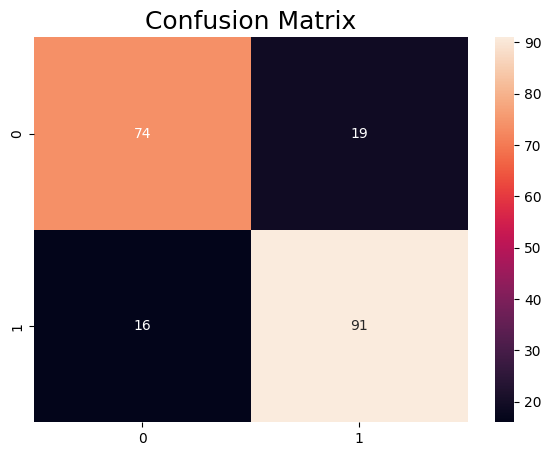

In [17]:
# Get the predictions from the classifier
y_pred = classifier.predict(X_test)

# Evaluate the classifier
class_report, conf_mat = evaluate_classification(y_test, y_pred)

---
# Exercise 2 &mdash; [Easy] Experiment: "Effect of random noise in class labels on classification"

**Group:** 8 <br> &nbsp;&nbsp; **Names / student numbers:** Luís Forti - 3981932 <br>
Marcell Slyuch - 3992616 <br>
Ntando Thato Mazinyane - 3987639 <br>

**Aim.** Everything above this line is the *baseline*: a Gaussian Naive&nbsp;Bayes model
trained on the clean credit-approval data. This experiment studies one data-quality
problem in isolation &mdash; **random noise in the class label** (mislabelled training
examples: annotation mistakes, data-entry errors in the target column, genuinely
ambiguous cases labelled inconsistently). We corrupt an increasing fraction of the
**training** labels, retrain, evaluate on a **clean** test set, and plot performance
against the noise level.

Questions we want to answer:

* How robust is Naive&nbsp;Bayes to mislabelled training data?
* Is the decline gradual, or is there a level of label noise beyond which the model
  collapses?
* How does label noise compare with input-feature noise (Exercise&nbsp;1)?

**Method (analogous to Exercise&nbsp;1, per the assignment).**

1. Keep the baseline code above untouched; record its performance as the 0&nbsp;% point.
2. Corrupt the **training labels only**. The test labels stay clean &mdash; otherwise the
   measured performance would be meaningless.
3. Loop over several noise levels (5&nbsp;%, 10&nbsp;%, 20&nbsp;%, 50&nbsp;%, &hellip;).
4. At each level, pick that fraction of the training rows at random and replace their
   class label with one drawn uniformly from the set of class values. Fresh rows each
   level.
5. Train on the corrupted training labels, evaluate on the clean test set.
6. Plot the results with the baseline as the 0&nbsp;% point.

> Save this file as `Group-N-DSAI-DQ-Lab-1-Exercise-2.ipynb` before submitting.

## Reusable pipeline

A clean, un-encoded copy of the data and the baseline preprocessing wrapped up so the split is made **once** on clean data. Only `y_train` is corrupted afterwards; `X_train`, `X_test` and `y_test` never change.

In [18]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

# Rebuild a CLEAN, un-encoded copy of the data, independent of the cells above.
_raw_arff, _meta = load_arff(path)
RAW = _raw_arff.dropna().reset_index(drop=True)

def _decode_if_bytes(v):
    return v.decode() if isinstance(v, bytes) else v

for _c in RAW.columns:
    if not pd.api.types.is_numeric_dtype(RAW[_c]):
        RAW[_c] = RAW[_c].map(_decode_if_bytes)

NOMINAL = [c for c in RAW.columns
           if not pd.api.types.is_numeric_dtype(RAW[c]) and c != "class"]
print(f"{len(RAW)} rows after dropping NaNs")

666 rows after dropping NaNs


In [19]:
def preprocess_and_split(df, random_state=100):
    """Baseline preprocessing (one-hot encode the nominal columns, drop the all-zero
    '_?' dummies) + the same fixed 70/30 split as the baseline cells above."""
    dummies = pd.get_dummies(df[NOMINAL])
    enc = pd.concat([df, dummies], axis=1).drop(columns=NOMINAL)
    enc = enc.drop(columns=[c for c in enc.columns if c.endswith("_?")])
    features = [c for c in enc.columns if c != "class"]
    return train_test_split(enc[features], enc["class"],
                            train_size=0.7, test_size=0.3, random_state=random_state)


# One fixed split, made ONCE on the clean data. In this experiment only y_train is
# ever corrupted -- X_train, X_test and y_test stay exactly as defined here.
X_train, X_test, y_train, y_test = preprocess_and_split(RAW)


def fit_eval(y_train_used):
    """Train Gaussian NB on the fixed X_train with the given (possibly noisy) training
    labels and score against the CLEAN test set."""
    model = GaussianNB().fit(X_train, y_train_used)
    y_pred = model.predict(X_test)
    return {
        "accuracy":  accuracy_score(y_test, y_pred),
        "f1_macro":  f1_score(y_test, y_pred, average="macro"),
    }


# Sanity check: with clean labels this must reproduce the baseline numbers above.
print("baseline (clean labels):", {k: round(v, 4) for k, v in fit_eval(y_train).items()})
print("training-label balance :", dict(y_train.value_counts()))

baseline (clean labels): {'accuracy': 0.825, 'f1_macro': 0.8237}
training-label balance : {'-': 260, '+': 206}


## Step 1 &mdash; the label-noise function

Replacement labels are drawn **uniformly from the set of class values**, exactly as Exercise&nbsp;1 does for a categorical attribute. Only the training labels are ever passed to this function.

In [20]:
CLASSES = sorted(pd.unique(y_train))
print("possible class labels:", CLASSES)


def add_label_noise(y, frac, rng):
    """Return a copy of the label Series `y` with a fraction `frac` of its entries
    replaced by a class value drawn uniformly at random from CLASSES. Fresh random
    rows on every call. Only ever applied to the TRAINING labels."""
    if frac <= 0:
        return y
    y = y.copy()
    n = int(round(frac * len(y)))
    idx = rng.choice(y.index.to_numpy(), size=n, replace=False)
    y.loc[idx] = rng.choice(CLASSES, size=n)
    return y

possible class labels: ['+', '-']


## Step 2 &mdash; run the sweep

Because a replacement label is drawn uniformly from `{+, -}`, about half of the
"corrupted" labels happen to be reassigned their original value. So the **effective**
fraction of *changed* labels is roughly half of `frac`; both are recorded
(`effective_flip`).

In [21]:
NOISE_LEVELS = [0.0, 0.02, 0.05, 0.10, 0.15, 0.20, 0.30, 0.40,
                0.50, 0.60, 0.70, 0.80, 0.90, 1.00]
N_REPEATS    = 50          # random draws per noise level, averaged for a smooth trend
BASE_SEED    = 42

records = []
for frac in NOISE_LEVELS:
    n_rep = 1 if frac == 0.0 else N_REPEATS
    for r in range(n_rep):
        rng = np.random.default_rng((BASE_SEED, int(round(frac * 1000)), r))
        y_noisy = add_label_noise(y_train, frac, rng)
        effective = float((y_noisy.to_numpy() != y_train.to_numpy()).mean())
        records.append({"noise": frac, "repeat": r,
                        "effective_flip": effective, **fit_eval(y_noisy)})

results = pd.DataFrame(records)
summary = results.groupby("noise").agg(["mean", "min", "max"])
summary.round(4)

repeat         effective_flip                 accuracy                \
        mean min max           mean     min     max     mean    min    max   
noise                                                                        
0.00     0.0   0   0         0.0000  0.0000  0.0000   0.8250  0.825  0.825   
0.02    24.5   0  49         0.0095  0.0043  0.0172   0.8274  0.820  0.850   
0.05    24.5   0  49         0.0241  0.0129  0.0343   0.8280  0.815  0.850   
0.10    24.5   0  49         0.0504  0.0322  0.0665   0.8272  0.810  0.845   
0.15    24.5   0  49         0.0757  0.0536  0.0923   0.8307  0.815  0.855   
0.20    24.5   0  49         0.0973  0.0794  0.1223   0.8290  0.805  0.855   
0.30    24.5   0  49         0.1494  0.1245  0.1738   0.8275  0.800  0.855   
0.40    24.5   0  49         0.1987  0.1674  0.2296   0.8141  0.775  0.840   
0.50    24.5   0  49         0.2494  0.2124  0.2897   0.8070  0.725  0.850   
0.60    24.5   0  49         0.3037  0.2554  0.3476   0.7706  0.585  0.840   
0.70    24.5   0  49         0.3505  0.3240  0.4120   0.7288  0.580  0.815   
0.80    24.5   0  49         0.3991  0.3562  0.4571   0.6666  0.510  0.770   
0.90    24.5   0  49         0.4461  0.3798  0.4893   0.6048  0.450  0.765   
1.00    24.5   0  49         0.4987  0.4421  0.5451   0.4876  0.290  0.650   

      f1_macro                  
          mean     min     max  
noise                           
0.00    0.8237  0.8237  0.8237  
0.02    0.8262  0.8185  0.8498  
0.05    0.8267  0.8137  0.8490  
0.10    0.8257  0.8084  0.8447  
0.15    0.8292  0.8133  0.8550  
0.20    0.8273  0.8019  0.8547  
0.30    0.8257  0.7966  0.8550  
0.40    0.8119  0.7670  0.8390  
0.50    0.8038  0.7234  0.8488  
0.60    0.7649  0.5510  0.8400  
0.70    0.7198  0.5520  0.8133  
0.80    0.6482  0.4356  0.7666  
0.90    0.5779  0.4193  0.7649  
1.00    0.4544  0.2874  0.6465

## Step 3 &mdash; plot performance vs. label-noise level

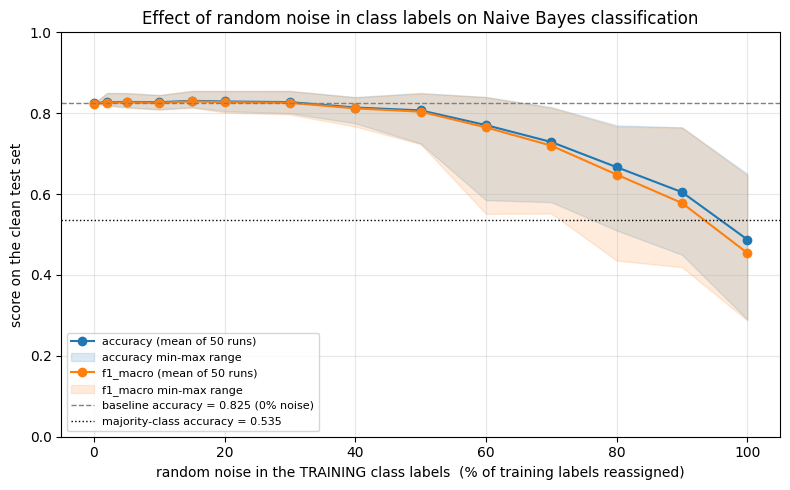

In [22]:
metrics = [("accuracy", "tab:blue"), ("f1_macro", "tab:orange")]
x = summary.index.to_numpy() * 100          # noise level as a percentage

fig, ax = plt.subplots(figsize=(8, 5))
for name, colour in metrics:
    mean = summary[(name, "mean")].to_numpy()
    lo   = summary[(name, "min")].to_numpy()
    hi   = summary[(name, "max")].to_numpy()
    ax.plot(x, mean, marker="o", color=colour,
            label=f"{name} (mean of {N_REPEATS} runs)")
    ax.fill_between(x, lo, hi, color=colour, alpha=0.15,
                   label=f"{name} min-max range")

baseline_acc = summary[("accuracy", "mean")].iloc[0]
ax.axhline(baseline_acc, ls="--", c="gray", lw=1,
           label=f"baseline accuracy = {baseline_acc:.3f} (0% noise)")

majority = y_test.value_counts(normalize=True).max()
ax.axhline(majority, ls=":", c="black", lw=1,
           label=f"majority-class accuracy = {majority:.3f}")

ax.set_xlabel("random noise in the TRAINING class labels  (% of training labels reassigned)")
ax.set_ylabel("score on the clean test set")
ax.set_title("Effect of random noise in class labels on Naive Bayes classification")
ax.set_ylim(0.0, 1.0)
ax.grid(alpha=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()